# Learning Parameterized ODE

Whilst learning equations from a single trajectory at a single parameter may be trivial and not too informative, we can learn a wealth of information about a system's dynamics by including parameterization in the learned model. In this tutorial, we will
1. Learn a parameterized ODE model that correctly reconstructs the flow in the conducting, circulating and chaotic regimes.
2. Perform nonlinear system analysis to investigate the bifurcation mechanism of the learned system.

In [44]:
# Import all required libraries

import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import sympy as sp
import warnings
from tqdm import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from IPython.display import Math, display
from scipy.optimize import fsolve

from sindy.plot_utils import init_plt_format
from sindy.selection import ps_stability_selection

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='Sparsity parameter is too big')
init_plt_format()

## Loading in the Trajectory Data

Let us load in a collection of trajectories ran at different Rayleigh numbers, and split them into training and validation data.

In [ ]:
data_dir: str = 'data/'
feature_names: list[str] = ['X', 'Y', 'Z', 'Ra']

# Specify which Rayleigh numbers to use for training and validation
ra_train: list[float] = [
    1e5, 5e5,
    1e6, 5e6,
    1e7, 5e7,
    1e8
]
ra_valid: list[float] = [5e4, 2e5, 2e6, 2e7, 2e8]

# Select the Prandtl number to load in
pr: float = 4

# Initialise list of training data
x_train: list[np.ndarray] = list()
t_train: list[np.ndarray] = list()
u_train: list[np.ndarray] = list()

# Initialise list of validation data
x_valid: list[np.ndarray] = list()
t_valid: list[np.ndarray] = list()
u_valid: list[np.ndarray] = list()

# Load training data from specified Rayleigh numbers
for ra in ra_train:
    data = np.load(data_dir+f"annulus_ra{ra:.3f}_pr{pr:.3f}.npz")
    x_train.append(data['x'][:, :3])
    t_train.append(data['t'])
    u_train.append(data['x'][:, 3:4])

# Load validation data from specified Rayleigh numbers
for ra in ra_valid:
    data = np.load(data_dir+f"annulus_ra{ra:.3f}_pr{pr:.3f}.npz")
    x_valid.append(data['x'][:, :3])
    t_valid.append(data['t'])
    u_valid.append(data['x'][:, 3:4])

Let us now visualize the loaded dataset.

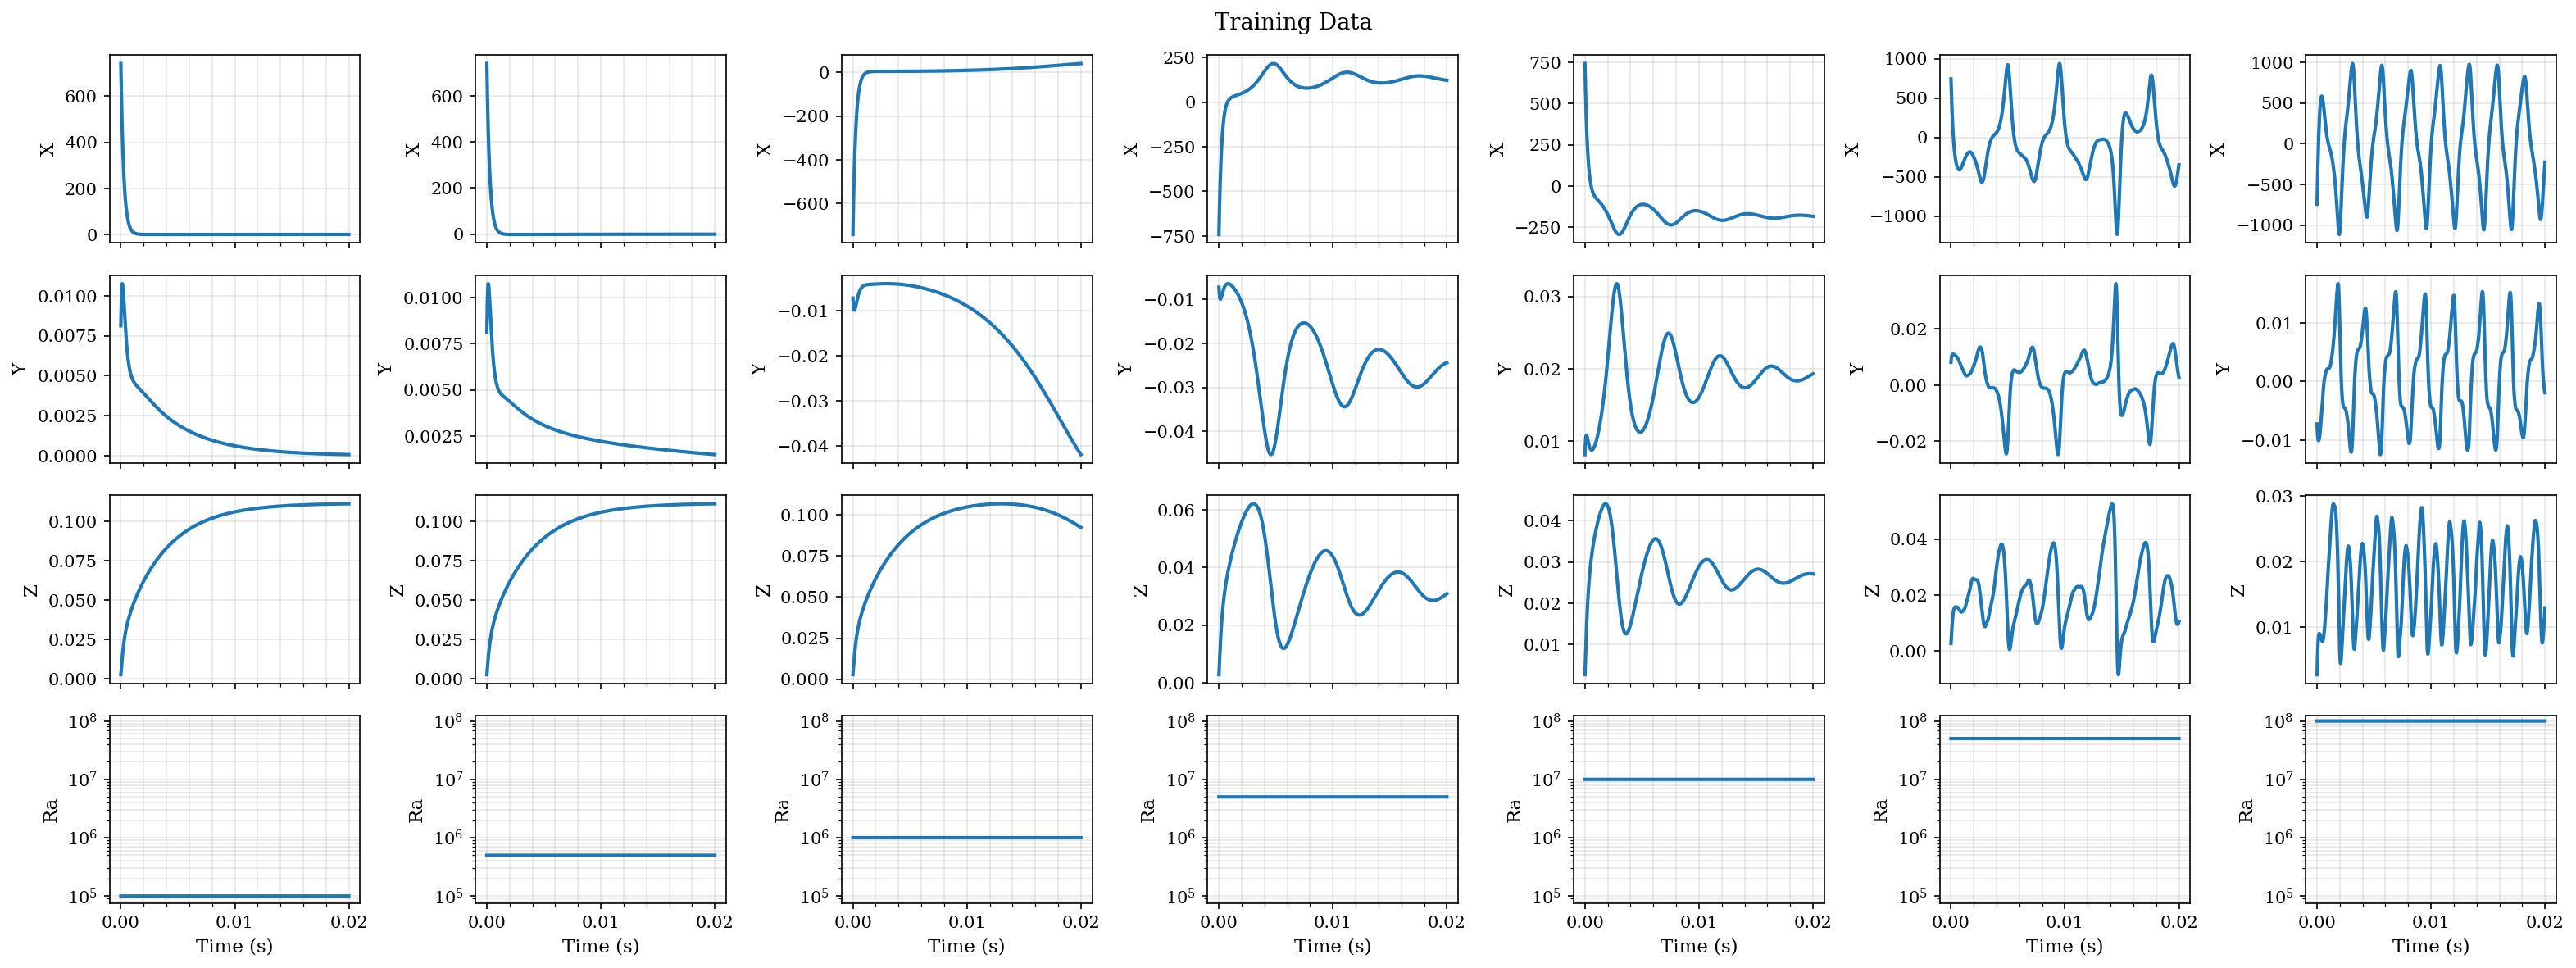

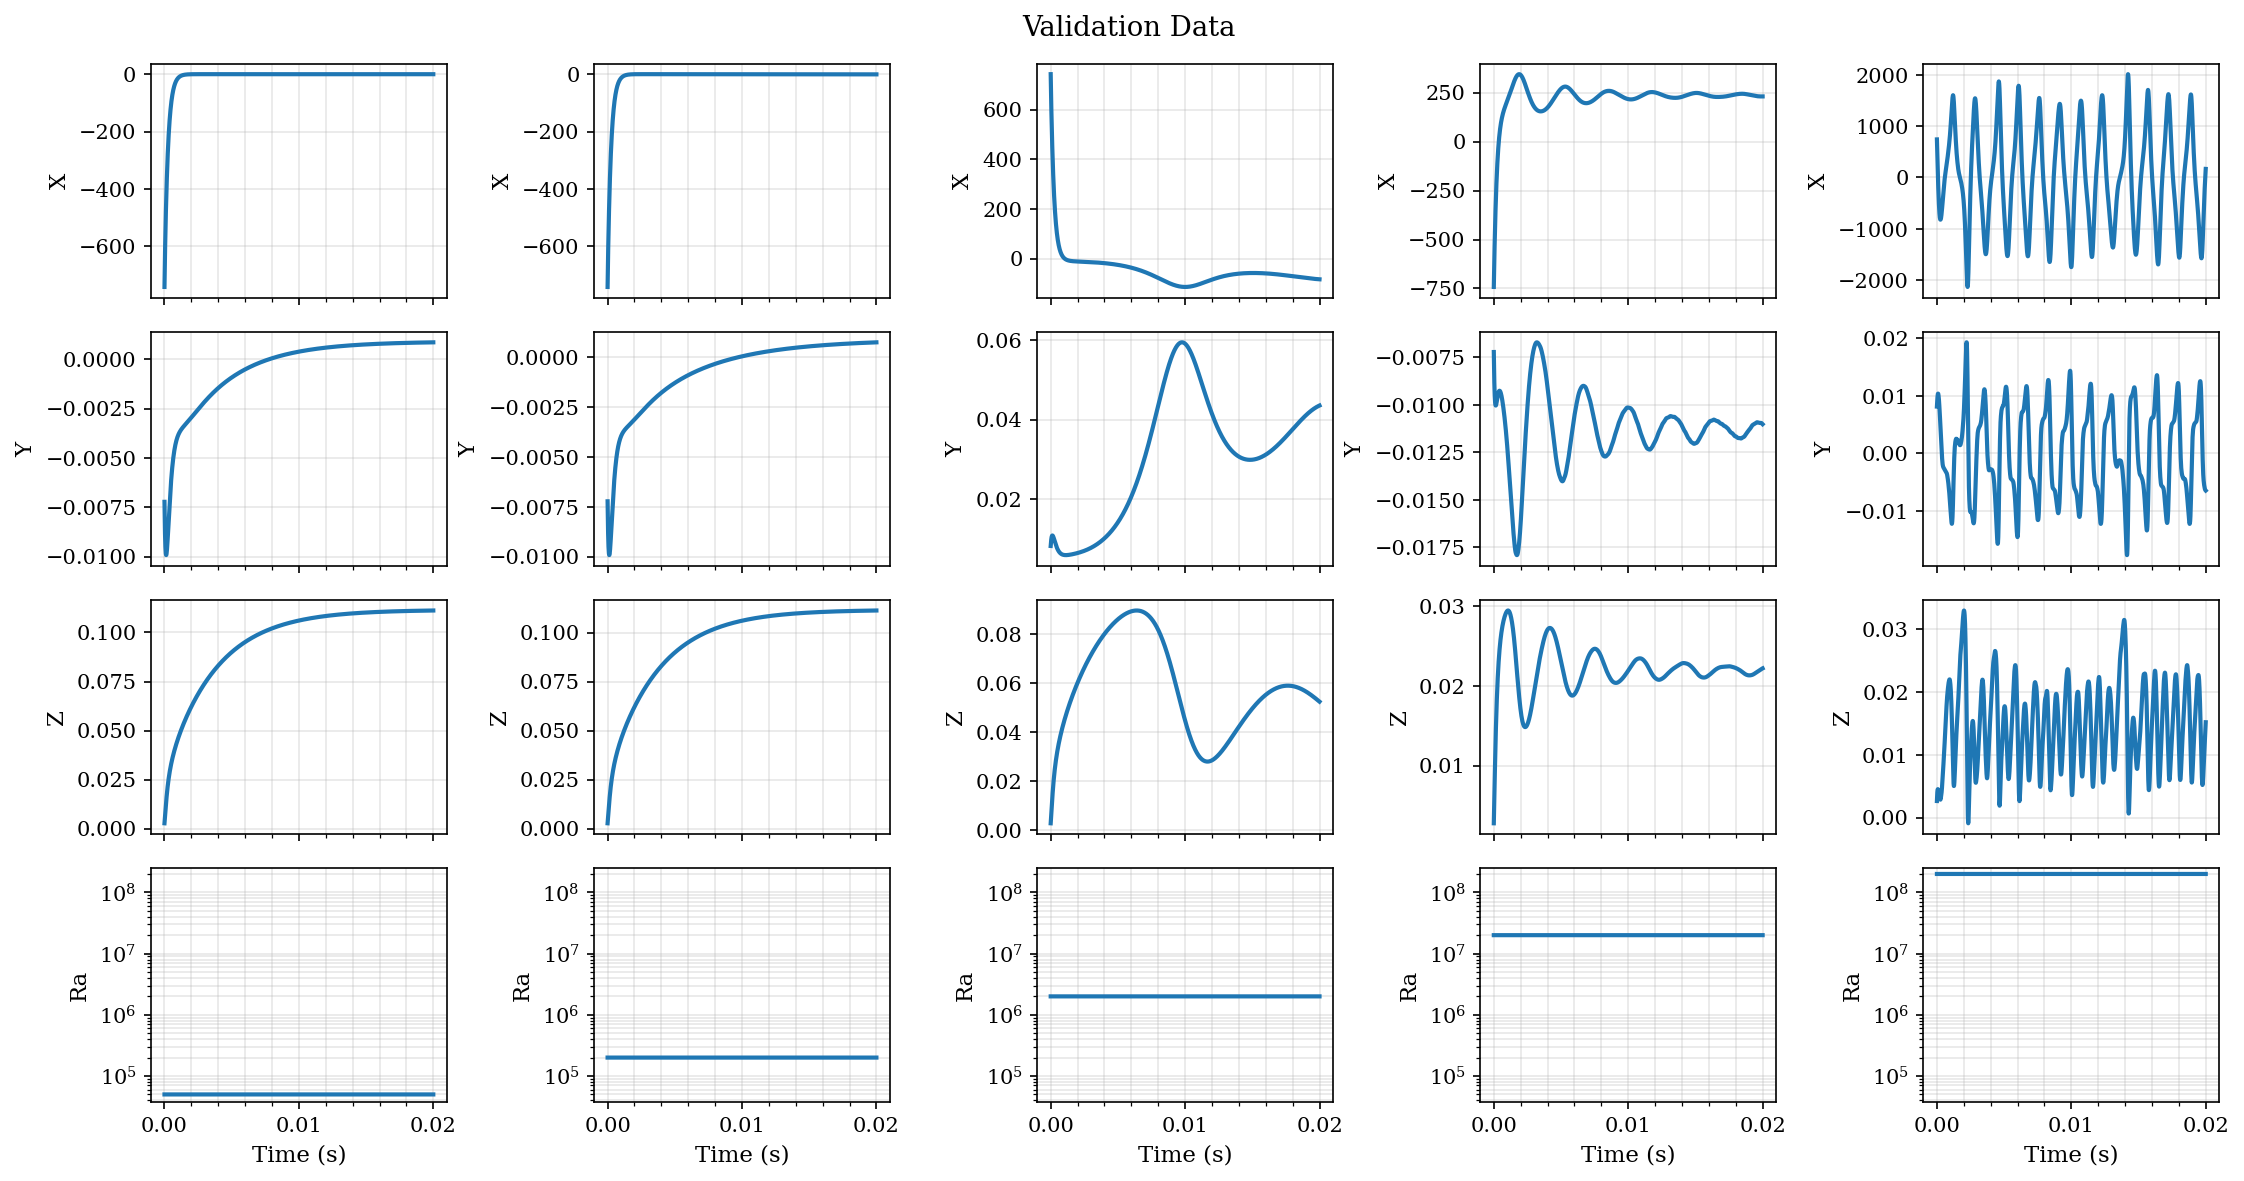

In [9]:
titles: list[str] = ['Training Data', 'Validation Data']

for idx, (x_list, t_list, u_list) in \
    enumerate(((x_train, t_train, u_train), (x_valid, t_valid, u_valid))):

    fig, axs = plt.subplots(
        4, len(x_list), sharex=True,
        figsize=(3*len(x_list), 8)
    )

    ra_min = min([ra[0,0] for ra in u_list])
    ra_max = max([ra[0,0] for ra in u_list])

    for paramIdx in range(len(x_list)):

        for stateIdx in range(3):
            axs[stateIdx, paramIdx].plot(
                t_list[paramIdx], x_list[paramIdx][:, stateIdx]
            )
            axs[stateIdx, paramIdx].set_ylabel(feature_names[stateIdx])

        axs[-1, paramIdx].plot(t_list[paramIdx], u_list[paramIdx][:, 0])
        axs[-1, paramIdx].set_ylabel('Ra')
        axs[-1, paramIdx].set_xlabel('Time (s)')
        axs[-1, paramIdx].set_yscale('log')
        axs[-1, paramIdx].set_ylim([
            0.75*ra_min,
            1.25*ra_max
        ])

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.suptitle(titles[idx])

Now let's split the data into training and validation datasets.

## Learning from a Collection of Trajectories

Similar to the previous tutorial, let us conduct a hyperparameter sweep to find the most appropriate $\lambda$ threshold for each state.

100%|██████████| 50/50 [00:27<00:00,  1.79it/s]


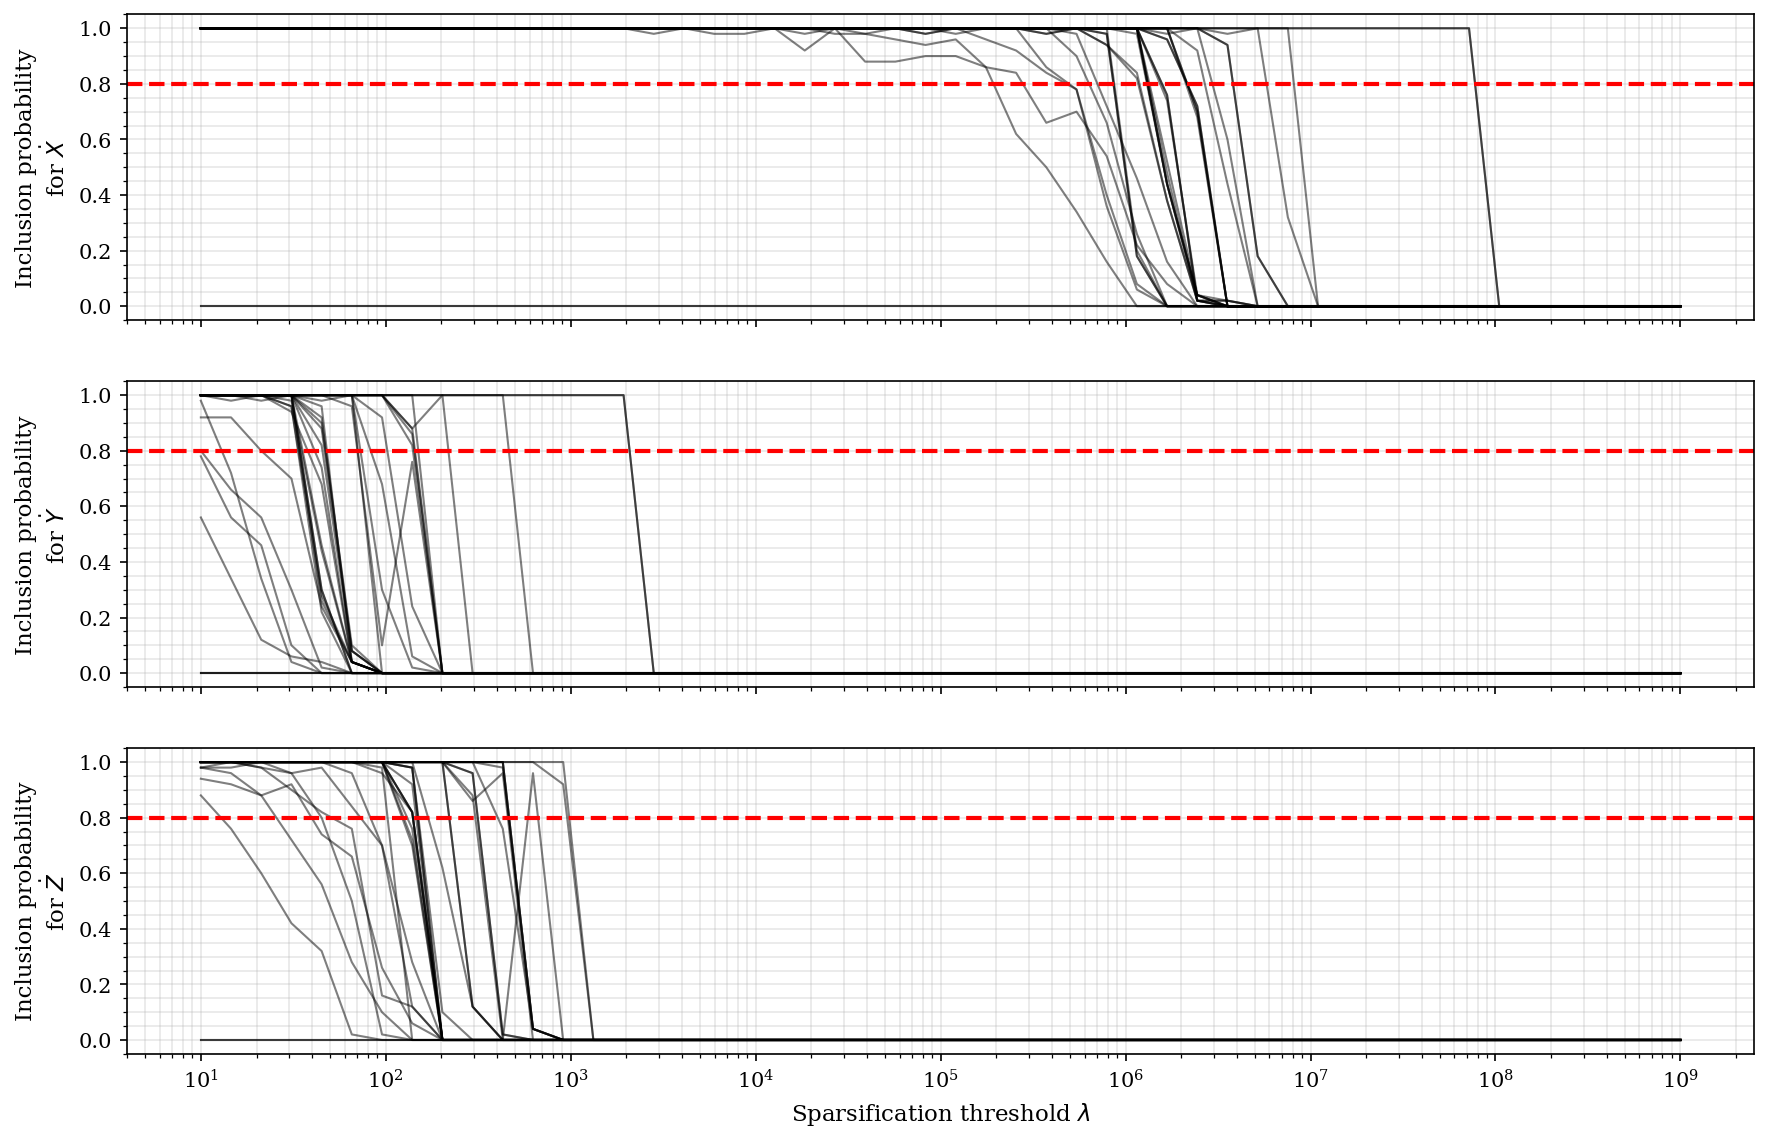

In [10]:
# Define SINDy parameters
lambdas = np.logspace(1, 9)
poly_order: int = 3
include_bias: bool = True
l2_norm: float = 0.001
normalize: bool = True

# Initialise the PySINDy library to use
lib = ps.PolynomialLibrary(poly_order, include_bias=include_bias)

# Select a model with stability selection
ps_stability_selection(
    x_train, t_train, u_train,
    lambdas=lambdas, l2_norm=l2_norm,
    ps_library=lib, normalize_columns=normalize, feature_names=feature_names
)

Once we have identified suitable sparsification threshold values, let us apply it to each state.

In [11]:
lambda_per_state: list[float] = [1e8, 500, 500]
models: list[ps.SINDy] = list()

lib = ps.PolynomialLibrary(poly_order, include_bias=include_bias)
fd_func = ps.FiniteDifference(4)

for idx in range(3):
    opti = ps.STLSQ(
        lambda_per_state[idx], l2_norm,
        normalize_columns=normalize
    )
    model = ps.SINDy(opti, lib, fd_func)
    model.fit(x_train, t_train, u=u_train, feature_names=feature_names)
    models.append(model)

model = models[0]

for idx in range(1, 3):
    model.optimizer.coef_[idx] = models[idx].optimizer.coef_[idx]

model.optimizer.coef_[np.abs(model.optimizer.coef_) < 0.01] = 0.0
model.print(precision=10)

(X)' = -4229.0325716158 X + -3.9403815549 Y Ra
(Y)' = 0.1072734415 X + -448.9587279356 Y + -6.1515012207 X Z
(Z)' = 34.6170452393 1 + -316.5388849646 Z + 8.1143539195 X Y


Note that PySINDy's `print` function will actually hide any coefficients below the specified precision value. For an symbolic analysis of the equation, it is better to perform an additional thresholding step to remove very small coefficients from the equation.


## Model Verification

Using the learned model, we can verify its accuracy by evaluating the time derivative using both training and validation data.

100%|██████████| 7/7 [00:00<00:00, 111.77it/s]


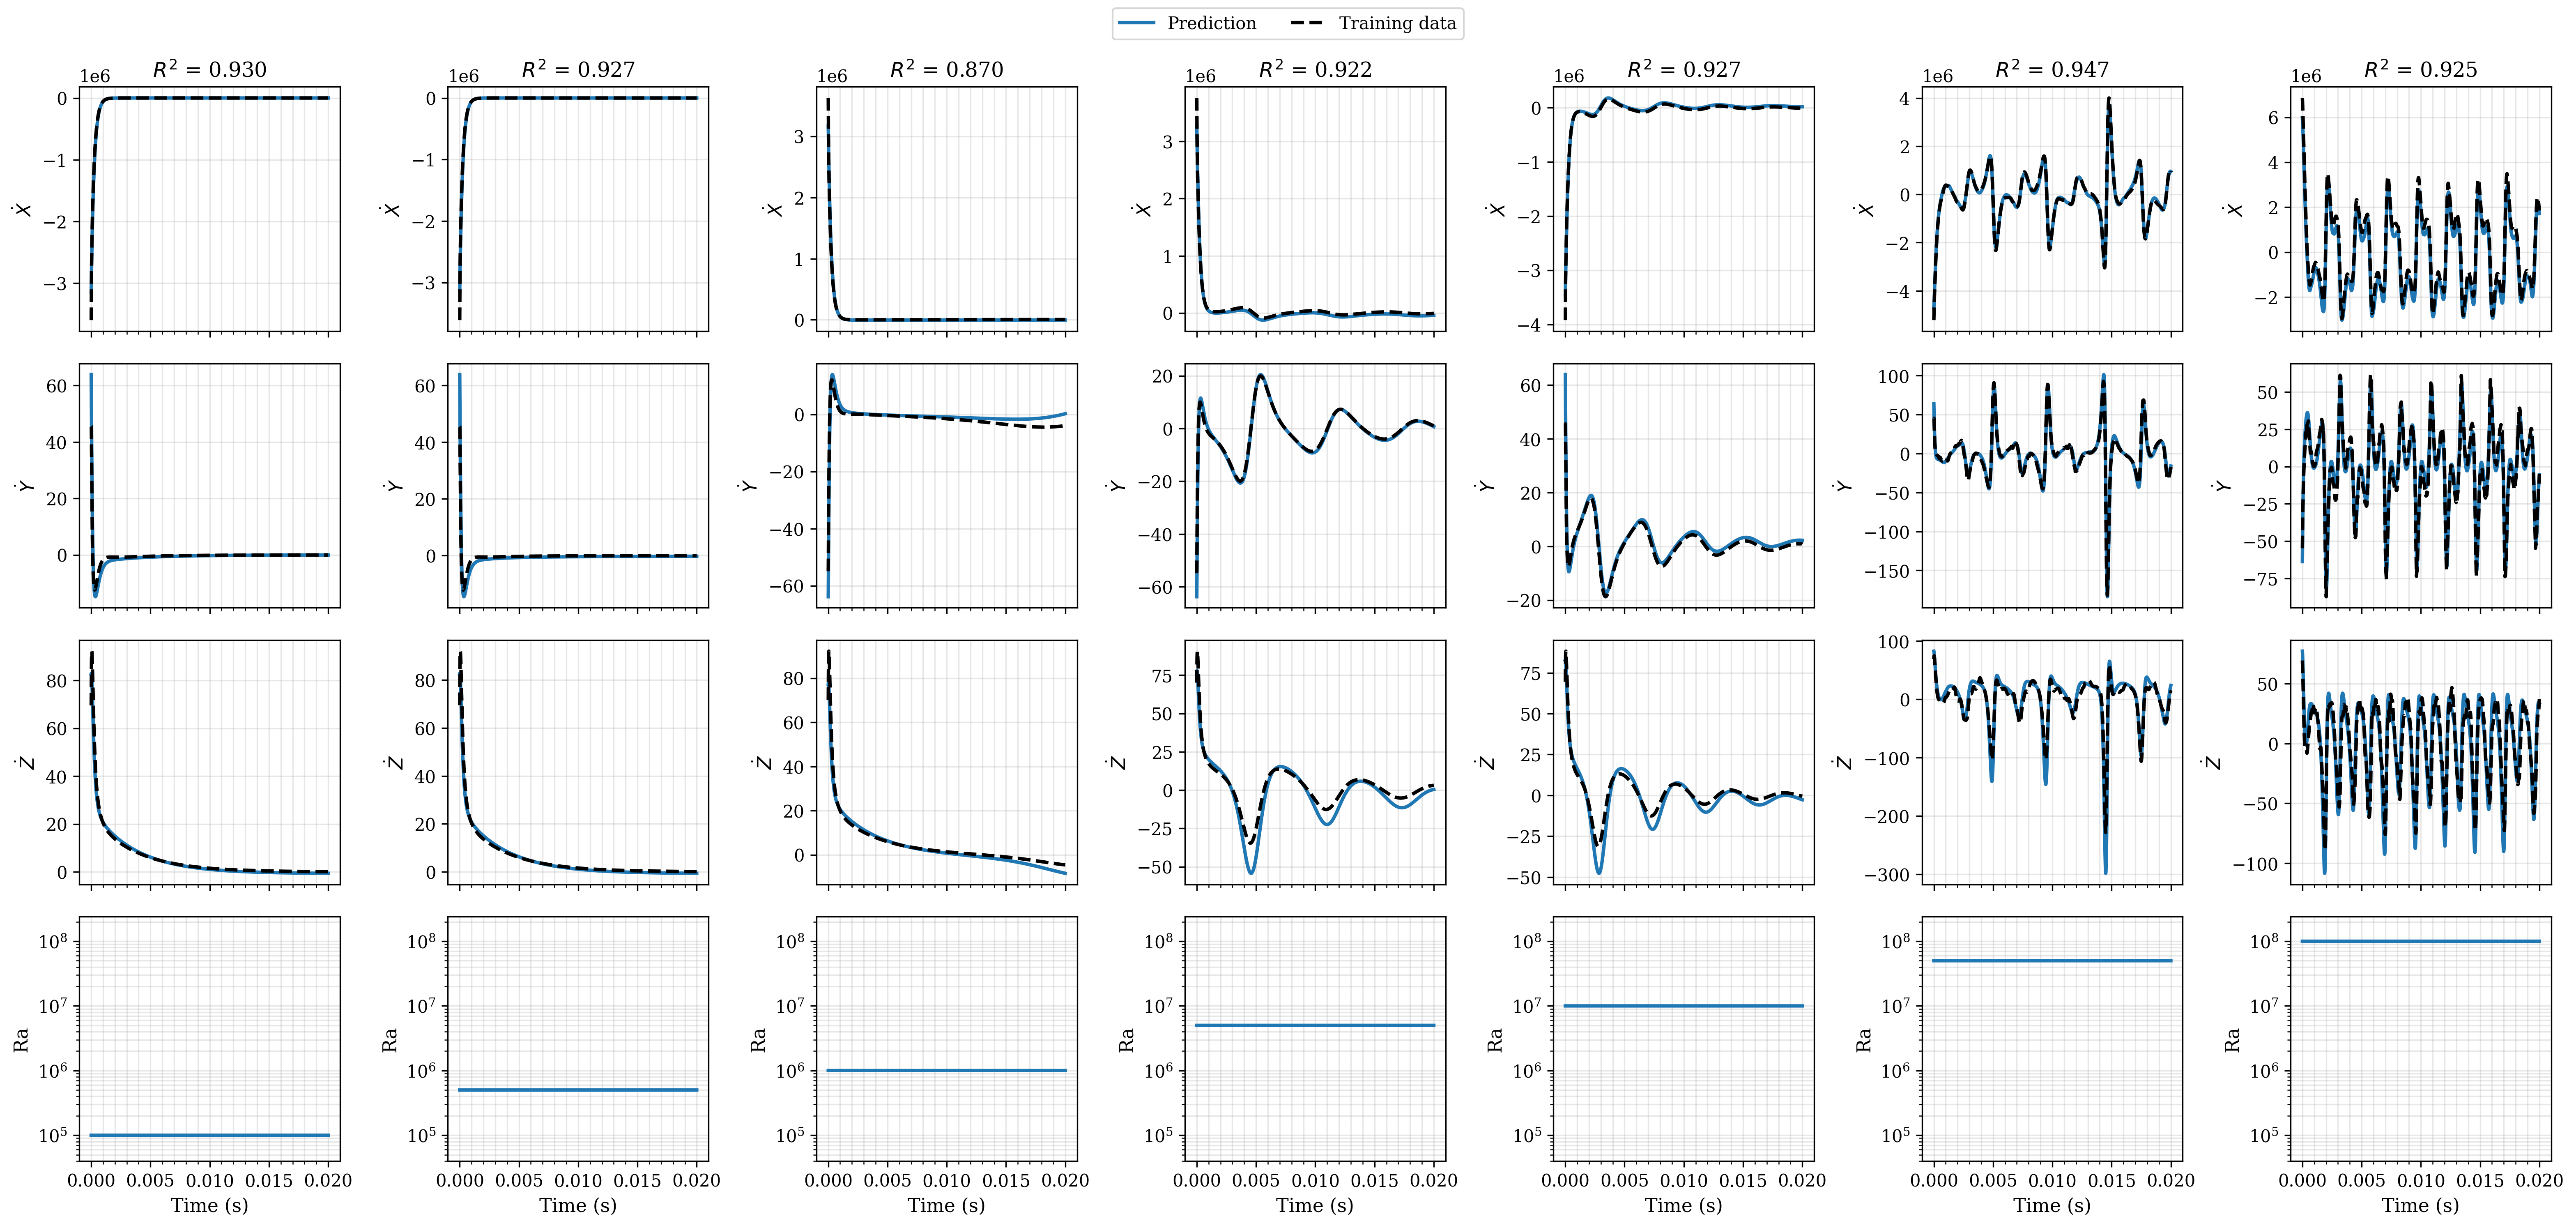

In [12]:
fig, axs = plt.subplots(
    4, len(x_train), sharex=True, figsize=(3*len(x_train), 10), dpi=300
)

for paramIdx in tqdm(range(len(x_train))):

    xdot = fd_func._differentiate(x_train[paramIdx], t_train[paramIdx])
    xdot_predict = model.predict(x_train[paramIdx], u_train[paramIdx])

    for stateIdx in range(3):

        if paramIdx == 0 and stateIdx == 0:
            label_predict = {'label': 'Prediction'}
            label_train = {'label': 'Training data'}
        else:
            label_predict = {}
            label_train = {}

        axs[stateIdx, paramIdx].plot(
            t_train[paramIdx], xdot_predict[:, stateIdx],
            **label_predict
        )
        axs[stateIdx, paramIdx].plot(
            t_train[paramIdx], xdot[:, stateIdx], '--k',
            **label_train
        )
        axs[stateIdx, paramIdx].set_ylabel(
            f'$\dot{{{feature_names[stateIdx]}}}$'
        )

    axs[-1, paramIdx].plot(t_train[paramIdx], u_train[paramIdx][:, 0])
    axs[-1, paramIdx].set_ylabel('Ra')
    axs[-1, paramIdx].set_xlabel('Time (s)')
    axs[-1, paramIdx].set_yscale('log')
    axs[-1, paramIdx].set_ylim([
        0.8*min([ra[0,0] for ra in u_list]),
        1.2*max([ra[0,0] for ra in u_list])
    ])

    r2 = r2_score(xdot, xdot_predict)
    axs[0, paramIdx].set_title(f'$R^2$ = {r2:.3f}')

fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.legend(loc='upper center', ncol=2);

And let us perform the same verification against validation data.

100%|██████████| 5/5 [00:00<00:00, 143.91it/s]


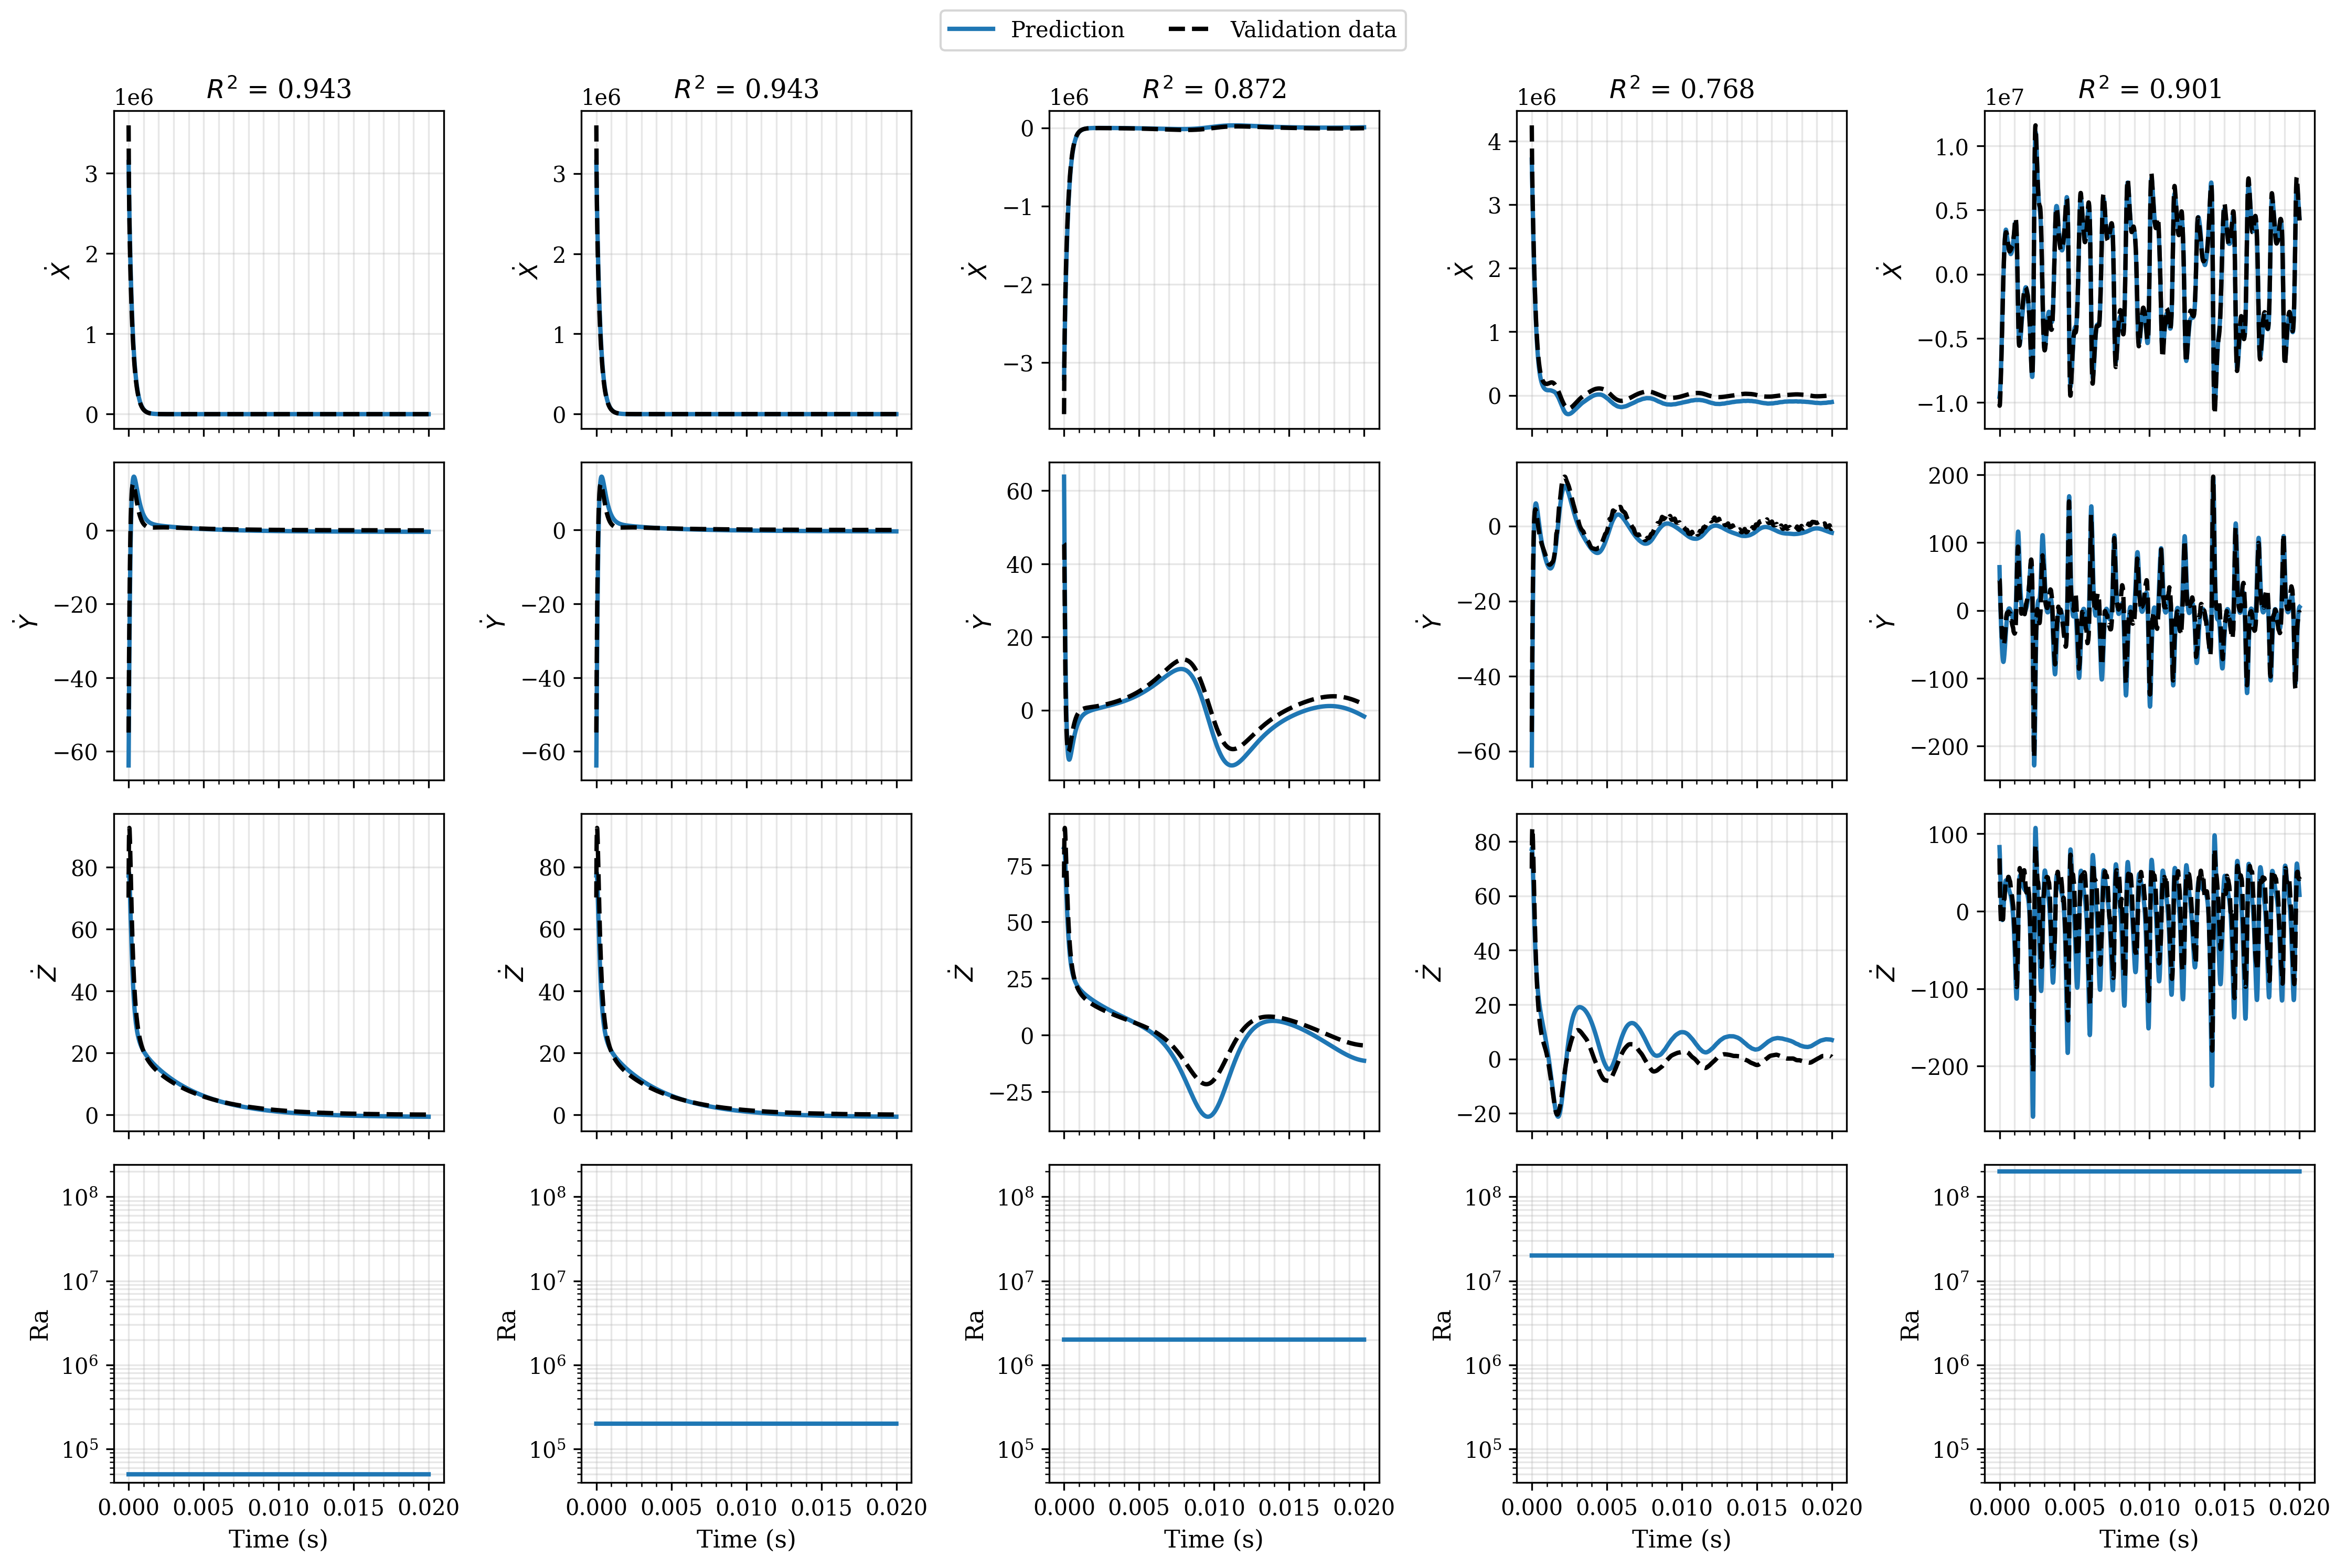

In [13]:
fig, axs = plt.subplots(
    4, len(x_valid), sharex=True, figsize=(3*len(x_valid), 10), dpi=300
)

for paramIdx in tqdm(range(len(x_valid))):

    xdot = fd_func._differentiate(x_valid[paramIdx], t_valid[paramIdx])
    xdot_predict = model.predict(x_valid[paramIdx], u_valid[paramIdx])

    for stateIdx in range(3):

        if paramIdx == 0 and stateIdx == 0:
            label_predict = {'label': 'Prediction'}
            label_valid = {'label': 'Validation data'}
        else:
            label_predict = {}
            label_valid = {}

        axs[stateIdx, paramIdx].plot(
            t_valid[paramIdx], xdot_predict[:, stateIdx],
            **label_predict
        )
        axs[stateIdx, paramIdx].plot(
            t_valid[paramIdx], xdot[:, stateIdx], '--k',
            **label_valid
        )
        axs[stateIdx, paramIdx].set_ylabel(
            f'$\dot{{{feature_names[stateIdx]}}}$'
        )

    axs[-1, paramIdx].plot(t_valid[paramIdx], u_valid[paramIdx][:, 0])
    axs[-1, paramIdx].set_ylabel('Ra')
    axs[-1, paramIdx].set_xlabel('Time (s)')
    axs[-1, paramIdx].set_yscale('log')
    axs[-1, paramIdx].set_ylim([
        0.8*min([ra[0,0] for ra in u_list]),
        1.2*max([ra[0,0] for ra in u_list])
    ])

    r2 = r2_score(xdot, xdot_predict)
    axs[0, paramIdx].set_title(f'$R^2$ = {r2:.3f}')

fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.legend(loc='upper center', ncol=2);

The model predictions appear to match quite well with the provided dataset, as well as matching the transitions from stable to periodic then chaotic flow. Let us now proceed to analyze the bifurcation mechanism of the learned nonlinear model to evaluate whether bifurcation has truly been captured accurately.


# Analysis with SymPy

SymPy is a Python library for symbolic mathematical analysis. Before we begin the analysis, we must first transfer the discovered `SINDy` model into mathematical equations defined using SymPy by extracting both the coefficients using `coefficients()` function as well as the polynomial powers extracted from `PolynomialLibrary.powers_`. Let us first define a helper function to format SymPy math output as Latex string.

In [14]:
def sp_latex(eqn, precision: int = 4):

    if hasattr(eqn, 'n'):
        eqn = eqn.n(precision)
        
    elif isinstance(eqn, dict):
        eqn = {
            var: val.n(precision) if hasattr(val, 'n') else val 
            for var, val in eqn.items()
        }
        
    elif isinstance(eqn, (list, tuple)):
        eqn = type(eqn)(
            val.n(precision) if hasattr(val, 'n') else val 
            for val in eqn
        )
        
    else:
        eqn = eqn

    return sp.latex(eqn)

Now let us transfer the equation into SymPy expression.

In [15]:
X, Y, Z, Ra = sp.symbols('X Y Z Ra', real=True)
states = [X, Y, Z, Ra]

poly_powers = model.feature_library.powers_
coef = model.coefficients().T

eqns: list = list()

for stateIdx in range(3):

    eqn = 0

    for libIdx in range(poly_powers.shape[0]):

        if coef[libIdx, stateIdx] != 0.0:
            term = coef[libIdx, stateIdx]
            for expIdx, exp in enumerate(poly_powers[libIdx]):
                term *= states[expIdx]**exp
            eqn += term

    eqns.append(eqn)

for idx, eqn in enumerate(eqns):
    display(Math(f'\dot{{{feature_names[idx]}}} = {sp_latex(eqn)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Equilibrium Points

When analyzing any nonlinear systems, it is important to find the equilibrium points of the system (if any) which would allow us to perform linear analysis at. This can be found by solving

$$ 0 = \frac{d}{dt} \begin{bmatrix} X \\ Y \\ Z \end{bmatrix} $$

In [16]:
eqs = sp.solve(eqns, states[:3])

for eqIdx, eq in enumerate(eqs):

    print(f'Equilibrium point {eqIdx:d}:')
    display(Math(sp_latex(eq)))

Equilibrium point 0:


<IPython.core.display.Math object>

Equilibrium point 1:


<IPython.core.display.Math object>

Equilibrium point 2:


<IPython.core.display.Math object>

From here, we can find that there are three equilibrium points. The first one does not vary with the Rayleigh number and is at a state where the flow does not move around the annulus as indicated by $L_{E_1}=X_{E_1}=0$.

The next two equilibrium points are a function of the Rayleigh number and shares the same $X_E$ and $Y_E$ values. Their $L_E$ values are also mirrored. This implies that in these equilibrium states, the flow is circulating around the annulus with a non-zero $L$ in either the clockwise or counter-clockwise direction.

Furthermore, by looking at the equation structure, the presence of a square root implies that the second and third equilibrium points only exist in a certain domain of Rayleigh numbers. We may perform a domain analysis using SymPy.

In [17]:
for eqIdx, eq in enumerate(eqs):

    print(f'\nDomain for equilibrium point {eqIdx:d}:')

    for eq_i in range(len(eq)):
        domain = sp.calculus.util.continuous_domain(eq[eq_i], Ra, sp.S.Reals)
        display(Math(
            fr'\text{{Valid domain for }}{states[eq_i]}_{{E_{eqIdx+1}}} = '
            + sp_latex(domain)
        ))


Domain for equilibrium point 0:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Domain for equilibrium point 1:


...

<IPython.core.display.Math object>


Domain for equilibrium point 2:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

From above, we can say that the second and third equilibrium points only exist beyond a critical Rayleigh number which we will denote as $Ra^\star_1$.


## Finding the Jacobian

In order to analyze the stability of the equilibrium points, we must first linearize the equation evaluating its Jacobian.

In [18]:
ode_system = sp.Matrix(eqns)
jacobian = ode_system.jacobian(states[:3])
display(Math(sp_latex(jacobian)))

<IPython.core.display.Math object>

The eigenvalues of the Jacobian evaluated at each equilibrium point would inform us of its stability characteristics. Let us define another helper function that creates a root-locus diagram that helps us visualize the stability change in the system.

In [19]:
def root_locus(eigvals, ras = np.logspace(-10, 10)):

    # Create list of parameterized eigenvalue functions
    eig_funcs = [
        sp.lambdify(Ra, eigval, modules='numpy') for eigval in eigvals
    ]

    # Plot root locus
    plt.figure(figsize=(5, 3))
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    for idx, func in enumerate(eig_funcs):

        roots = func(ras)
        if not isinstance(roots, np.ndarray):
            roots = np.array([roots], dtype=np.complex128)
        else:
            roots = roots.astype(np.complex128)
        line = plt.plot(roots.real, roots.imag, label=f'$\lambda_{idx}$')
        plt.plot(
            roots[~np.isnan(roots)][0].real, roots[~np.isnan(roots)][0].imag,
            'x', color=line[0].get_color(), markersize=8
        )

    plt.xlabel('$\Re(\lambda)$')
    plt.ylabel('$\Im(\lambda)$')
    plt.tight_layout()
    plt.legend();

## Stability Analysis: Conducting State

Let us first evaluate the Jacobian at the equilibrium point.

In [20]:
eqIdx = 0

jacob_eq1 = jacobian.subs([
    (X, eqs[eqIdx][0]),
    (Y, eqs[eqIdx][1]),
    (Z, eqs[eqIdx][2])
])
display(Math(sp_latex(jacob_eq1)))

<IPython.core.display.Math object>

We may then compute the eigenvalues of the above matrix.

In [21]:
eig_eq1 = jacob_eq1.eigenvals()
for idx, (eigval, eigrep) in enumerate(eig_eq1.items()):

    display(Math(
        fr'\lambda_{idx} = {sp_latex(eigval)} \text{{ with }} {eigrep:d}'
        + fr'\text{{ repetition.}}'
    ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

As can be seen from the equation structure, all eigenvalues are real and negative when $Ra$ is small. However, $\lambda_1$ can become positive at a sufficiently large $Ra$ as seen in the root locus plot below.

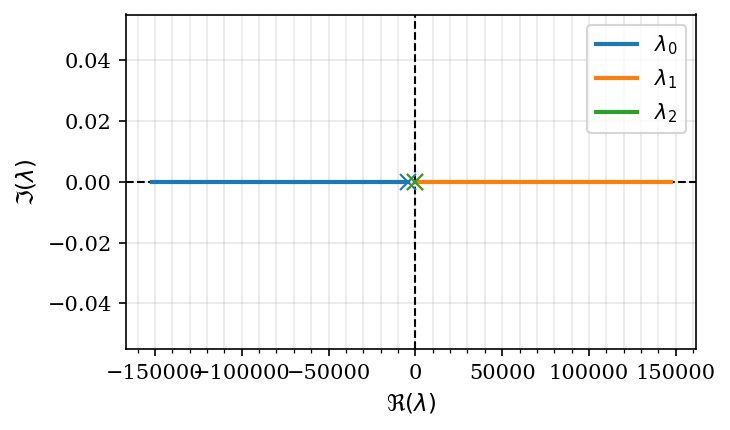

In [22]:
root_locus(eig_eq1.keys())

We can attempt to find the point at which this occurs by solving $0 = \lambda(Ra).$

In [23]:
for idx, eig in enumerate(eig_eq1.keys()):

    crit_ra = sp.solve([eig], [Ra])

    print(
        f'\nChecking if critical Rayleigh number exists that can result in'
        + f' bifurcation for λ_{idx:d}'
    )
    if len(crit_ra) == 0:
        print('No critical Rayleigh found.')
    else:
        display(Math(
            fr'\text{{Bifurcation occurs at }} Ra = {sp_latex(crit_ra[0][0])}'
        ))
        crit_ra1 = crit_ra


Checking if critical Rayleigh number exists that can result in bifurcation for λ_0
No critical Rayleigh found.

Checking if critical Rayleigh number exists that can result in bifurcation for λ_1


<IPython.core.display.Math object>


Checking if critical Rayleigh number exists that can result in bifurcation for λ_2
No critical Rayleigh found.


This corresponds with the value of $Ra^\star_1$ found earlier. This phenomenon is known as the pitchfork bifurcation where a stable equilibrium point becomes unstable and give rise to two additional stable equilibrium points.


## Stability Analysis: Circulatory State

Let us now analyze the stability of the next two equilibrium points by first evaluating the Jacobian at those points.

In [24]:
eqIdx = -1

jacob_eq2 = jacobian.subs([
    (X, eqs[eqIdx][0]),
    (Y, eqs[eqIdx][1]),
    (Z, eqs[eqIdx][2])
])
display(Math(sp_latex(jacob_eq2)))

<IPython.core.display.Math object>

Then we may solve for its eigenvalues.

In [25]:
eig_eq2 = jacob_eq2.eigenvals()
for idx, (eigval, eigrep) in enumerate(eig_eq2.items()):

    display(Math(
        fr'\lambda_{idx} = {sp_latex(eigval)} \text{{ with }} {eigrep:d}'
        + fr'\text{{ repetition.}}'
    ))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Sometimes, the equations may be too difficult to analyze symbolically. However, from the root locus plot below, we can see that two of the oscillatory eigenvalues eventually lose its stability as it crosses the imaginary axis.

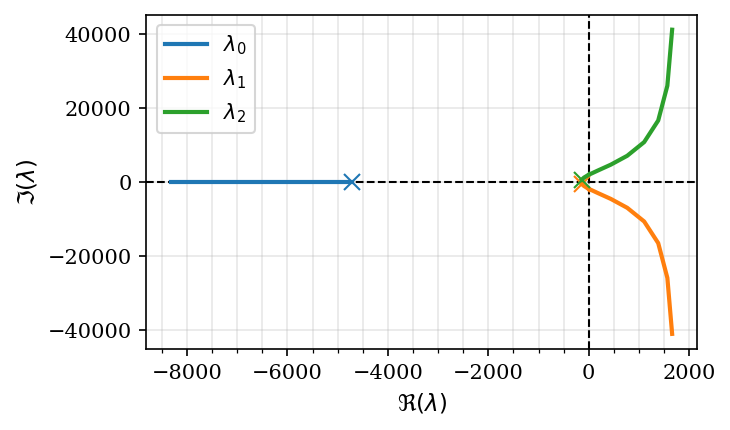

In [26]:
root_locus(eig_eq2.keys())

We may either solve $0=\lambda(Ra)$ (numerically and not symbolically due to the complexity of the equation), or exploit stability criterion such as the Routh–Hurwitz stability criterion which is a necessary and sufficient stability condition for linear systems. We may perform this analysis on the characteristic polynomial of the Jacobian evaluated as:

In [27]:
char_poly = jacob_eq2.charpoly(sp.symbols('lambda'))
display(Math(sp_latex(char_poly.as_expr())))

<IPython.core.display.Math object>

For a cubic polynomial defined as

$$ 0 = s^3 + c_2 s^2 + c_1 s + c_0, $$

the [Routh–Hurwitz stability criterion](https://en.wikipedia.org/wiki/Routh%E2%80%93Hurwitz_stability_criterion) states that it must satisfy

$$
\begin{aligned}
    c_i &> 0 \quad \text{for} \quad i = \{0, 1, 2\}, \\
    c_2 c_1 - c_0 &> 0,
\end{aligned}
$$

to be stable.

In [28]:
char_poly_coefs = char_poly.all_coeffs()

c2 = char_poly_coefs[1]
c1 = char_poly_coefs[2]
c0 = char_poly_coefs[3]

conditions = [c0 > 0, c1 > 0, c2 > 0]
ra_stable_domain = sp.reduce_inequalities(conditions, Ra)
display(Math(
    fr'\text{{Domain of Ra where coefficients are positive}} = '
    + fr'{sp_latex(ra_stable_domain)}'
))

rh_func = sp.lambdify(Ra, c2*c1-c0, modules='numpy')

crit_ra2 = fsolve(rh_func, 7e7)
display(Math(
    fr'\text{{Bifurcation occurs at }} Ra^\star_2 = {sp_latex(crit_ra2)}'
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

We obtain a second critical Rayleigh number $Ra^\star_2$ where the all equilibrium points become unstable. When $Ra > Ra^\star_2$, the flow becomes fully chaotic.

Here, we have demonstrated an approach to learning a low-dimensional ODE system from a chaotic thermosyphon flow. We may now re-visualize our data in relation to the computed critical bifurcation values.

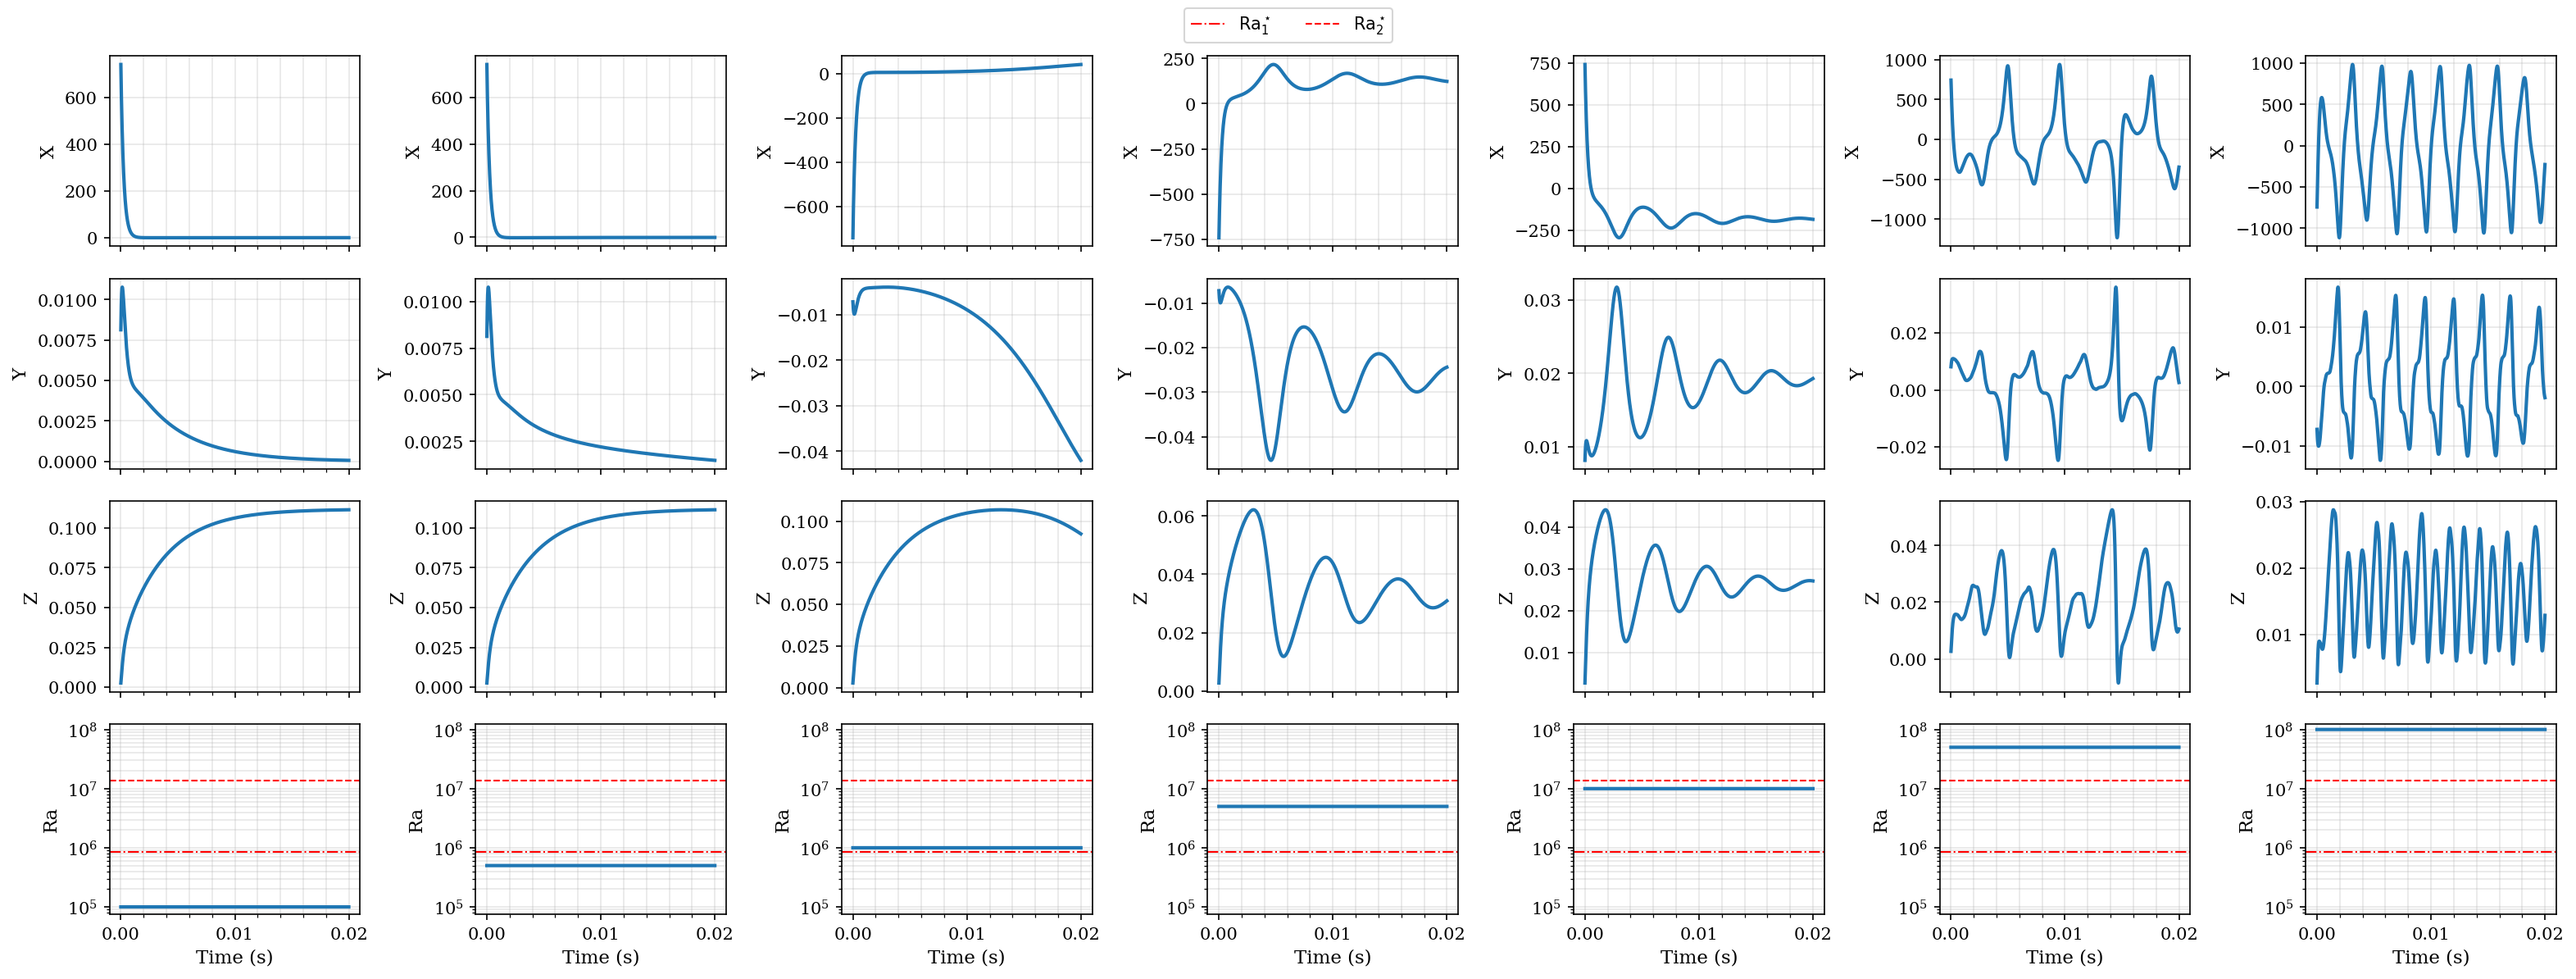

In [29]:
fig, axs = plt.subplots(
    4, len(x_train), sharex=True,
    figsize=(3*len(x_train), 8)
)

for paramIdx in range(len(x_train)):

    for stateIdx in range(3):
        axs[stateIdx, paramIdx].plot(
            t_train[paramIdx], x_train[paramIdx][:, stateIdx]
        )
        axs[stateIdx, paramIdx].set_ylabel(feature_names[stateIdx])

    if paramIdx == 0:
        crit_ra1_label = {'label': r'$\text{Ra}_1^\star$'}
        crit_ra2_label = {'label': r'$\text{Ra}_2^\star$'}
    else:
        crit_ra1_label = {}
        crit_ra2_label = {}

    axs[-1, paramIdx].axhline(
        crit_ra1, linestyle='-.', color='red', linewidth=1,
        **crit_ra1_label
    )
    axs[-1, paramIdx].axhline(
        crit_ra2, linestyle='--', color='red', linewidth=1,
        **crit_ra2_label
    )
    axs[-1, paramIdx].plot(t_train[paramIdx], u_train[paramIdx][:, 0])
    axs[-1, paramIdx].set_ylabel('Ra')
    axs[-1, paramIdx].set_xlabel('Time (s)')
    axs[-1, paramIdx].set_yscale('log')
    axs[-1, paramIdx].set_ylim([
        0.75*min([ra[0,0] for ra in u_train]),
        1.25*max([ra[0,0] for ra in u_train])
    ])

fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.legend(loc='upper center', ncol=2);

To verify if a given trajectory has transitioned from periodic orbits to chaotic trajectories, we may analyze its frequency power spectrum. For periodic trajectories, we should expect clean and distinct peaks in the power spectrum. Whereas, chaotic trajectories with aperiodicity would create a noisy power spectrum.

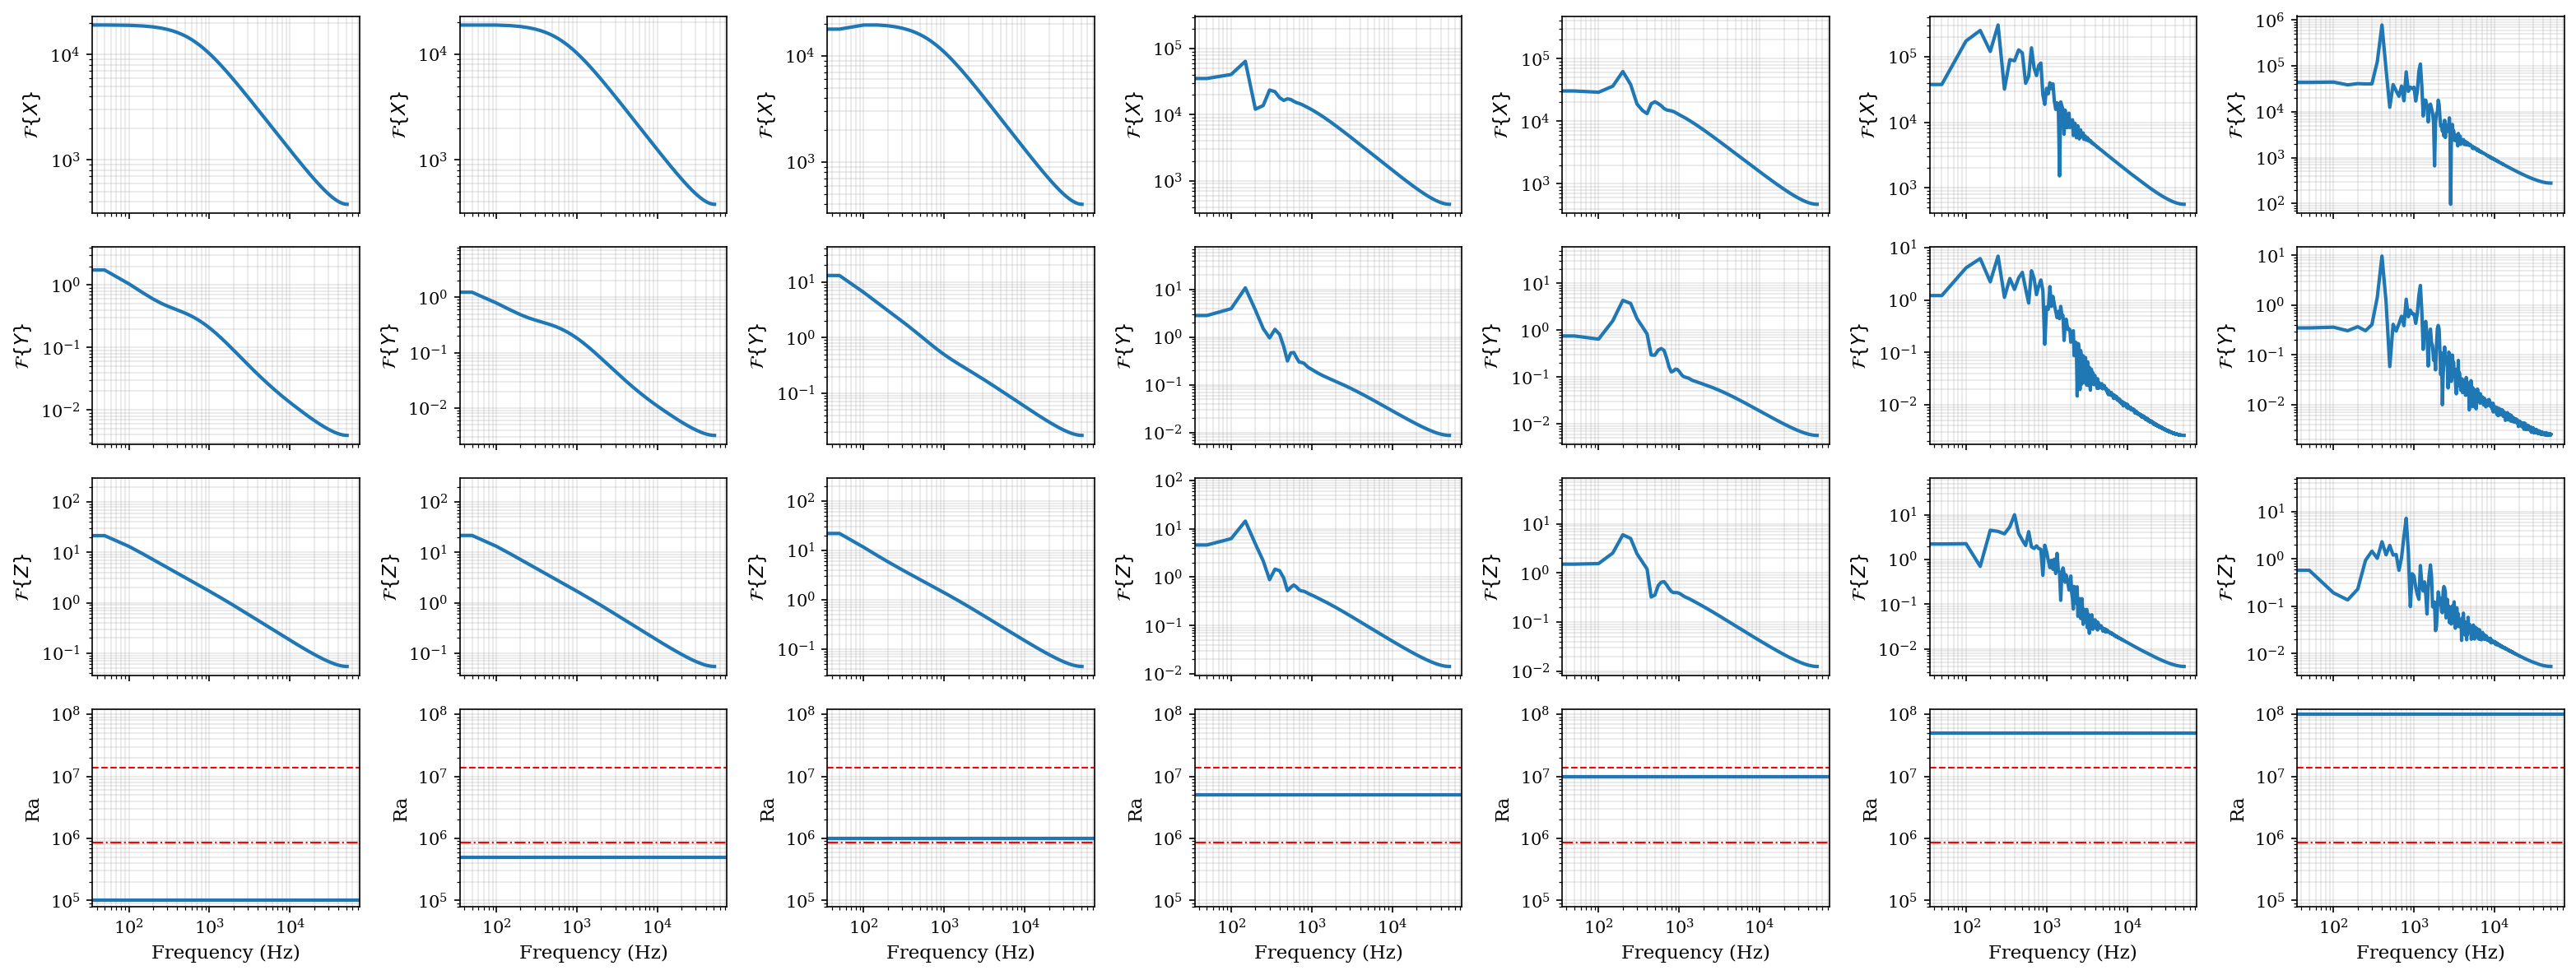

In [30]:
fig, axs = plt.subplots(
    4, len(x_train), sharex=True,
    figsize=(3*len(x_train), 8)
)

for paramIdx in range(len(x_train)):

    freq = np.fft.rfftfreq(x_train[paramIdx].shape[0], t_train[paramIdx][1] - t_train[paramIdx][0])
    xhat = np.fft.rfft(x_train[paramIdx], axis=0)

    if paramIdx == 0:
        crit_ra1_label = {'label': r'$\text{Ra}_1^\star$'}
        crit_ra2_label = {'label': r'$\text{Ra}_2^\star$'}
    else:
        crit_ra1_label = {}
        crit_ra2_label = {}

    for stateIdx in range(3):
        axs[stateIdx, paramIdx].plot(
            freq, np.abs(xhat[:, stateIdx])
        )
        axs[stateIdx, paramIdx].set_ylabel(f'$\mathcal{{F}} \{{{feature_names[stateIdx]}\}}$')
        axs[stateIdx, paramIdx].set_yscale('log')
        axs[stateIdx, paramIdx].set_xscale('log')

    axs[-1, paramIdx].axhline(
        crit_ra1, linestyle='-.', color='red', linewidth=1,
        **crit_ra1_label
    )
    axs[-1, paramIdx].axhline(
        crit_ra2, linestyle='--', color='red', linewidth=1,
        **crit_ra2_label
    )
    axs[-1, paramIdx].axhline(u_train[paramIdx][0, 0])
    axs[-1, paramIdx].set_ylabel('Ra')
    axs[-1, paramIdx].set_xlabel('Frequency (Hz)')
    axs[-1, paramIdx].set_yscale('log')
    axs[-1, paramIdx].set_ylim([
        0.8*min([ra[0,0] for ra in u_train]),
        1.2*max([ra[0,0] for ra in u_train])
    ])

fig.tight_layout()

As seen, the model does correctly predict the point at which bifurcation occurs.


## Bifurcation Verification

From the work of [(Huang et al, 2023)](https://arxiv.org/abs/2307.13146), they have derived a low-dimensional ODE system following a similar method as Lorenz's original work on his chaotic system, using a truncated Galerkin expansion of the flow. Their 3 state dynamical system is defined by

$$
\begin{aligned}
    \dot{X} &= -\text{Ra} \text{Pr} Y - \alpha \text{Pr} X, \\
    \dot{Y} &= -kX(Z-z_1) - \beta Y, \\
    \dot{Z} &= kXY - \beta(Z-z_0),
\end{aligned}
$$

where the constants $\alpha$, $\beta$, $k$, $z_0$ and $z_1$ are all functions of $R_1$, the inner wall radius of the annulus. The outer wall radius $R_2$ was assumed to be fixed to $1/2$. From an analysis of their derived system, we can find their critical bifurcation values.

In [31]:
# Initialise r0 (inner wall radius)
r0 = 0.4

# Calculate alpha, beta, and delta
alpha = 48 / (1 - 2*r0)**2

beta = 48 * (1 + 4*r0**2) / ((1 - 2*r0)**2 * (1 + 6*r0 + 16*r0**2))

delta = 3 * (1 + 12*r0**2) / ((1 - 2*r0)**2 * (1 + 6*r0 + 16*r0**2))

# Calculate k
k_num = (1 - 2*r0) * (1 - 6*r0 - 4*r0**2 - 88*r0**3 + 32*r0**4) \
    - 96*r0**3 * np.log(2*r0)
k_den = (1 - 2*r0)**5 * (1 + 6*r0 + 16*r0**2)
k = 24 * (k_num / k_den)

# Calculate gamma
gamma_num = (1 - 4*r0**2) * (1 - 8*r0 - 224*r0**3 - 80*r0**4) \
    - 192*r0**3 * (1 + 2*r0 + 4*r0**2) * np.log(2*r0)
gamma_den = (1 - 2*r0)**5 * (1 + 2*r0) * (1 + 6*r0 + 16*r0**2)
gamma = gamma_num / gamma_den

# y values
y0 = delta/beta
y1 = gamma/k
dy = y0-y1

# Compute the Critical Rayleigh numbers
crit_ra1_huang = alpha*beta/k/dy
crit_ra2_huang = alpha**2 * pr / k / dy * (alpha*pr + 4*beta) / (alpha*pr - 2*beta)
print(f"Ra_1*: {crit_ra1_huang:.3e}")
print(f"Ra_2*: {crit_ra2_huang:.3e}")

Ra_1*: 7.252e+05
Ra_2*: 1.559e+07


We can then compute the relative percentage error between the learned bifurcation point and the ones found by [(Huang et al, 2023)](https://arxiv.org/abs/2307.13146).

In [32]:
ra_crit1_rel_err = (crit_ra1 - crit_ra1_huang)/crit_ra1_huang
print(fr'Relative error of Ra_1* = {ra_crit1_rel_err.flat[0]*100:.2f}%')

ra_crit2_rel_err = (crit_ra2 - crit_ra2_huang)/crit_ra2_huang
print(fr'Relative error of Ra_2* = {ra_crit2_rel_err.flat[0]*100:.2f}%')

Relative error of Ra_1* = 17.50%
Relative error of Ra_2* = -12.40%


As alluded to in [3-1 Thermosyphon Flow](./3-1%20Thermosyphon%20Flow.ipynb) tutorial, due to the coarse mesh used, physics errors have been introduced which results in unknown physics phenomena. Therefore, resulting in a mismatch in bifurcation parameters. However, since SINDy learned the equations directly from data, it can also capture any unmodeled physics from data as well.

If we compare the prediction from our learned model from data with the analytically derived system, we can see that the learned system captures the physics errors.

100%|██████████| 5/5 [00:00<00:00,  8.84it/s]


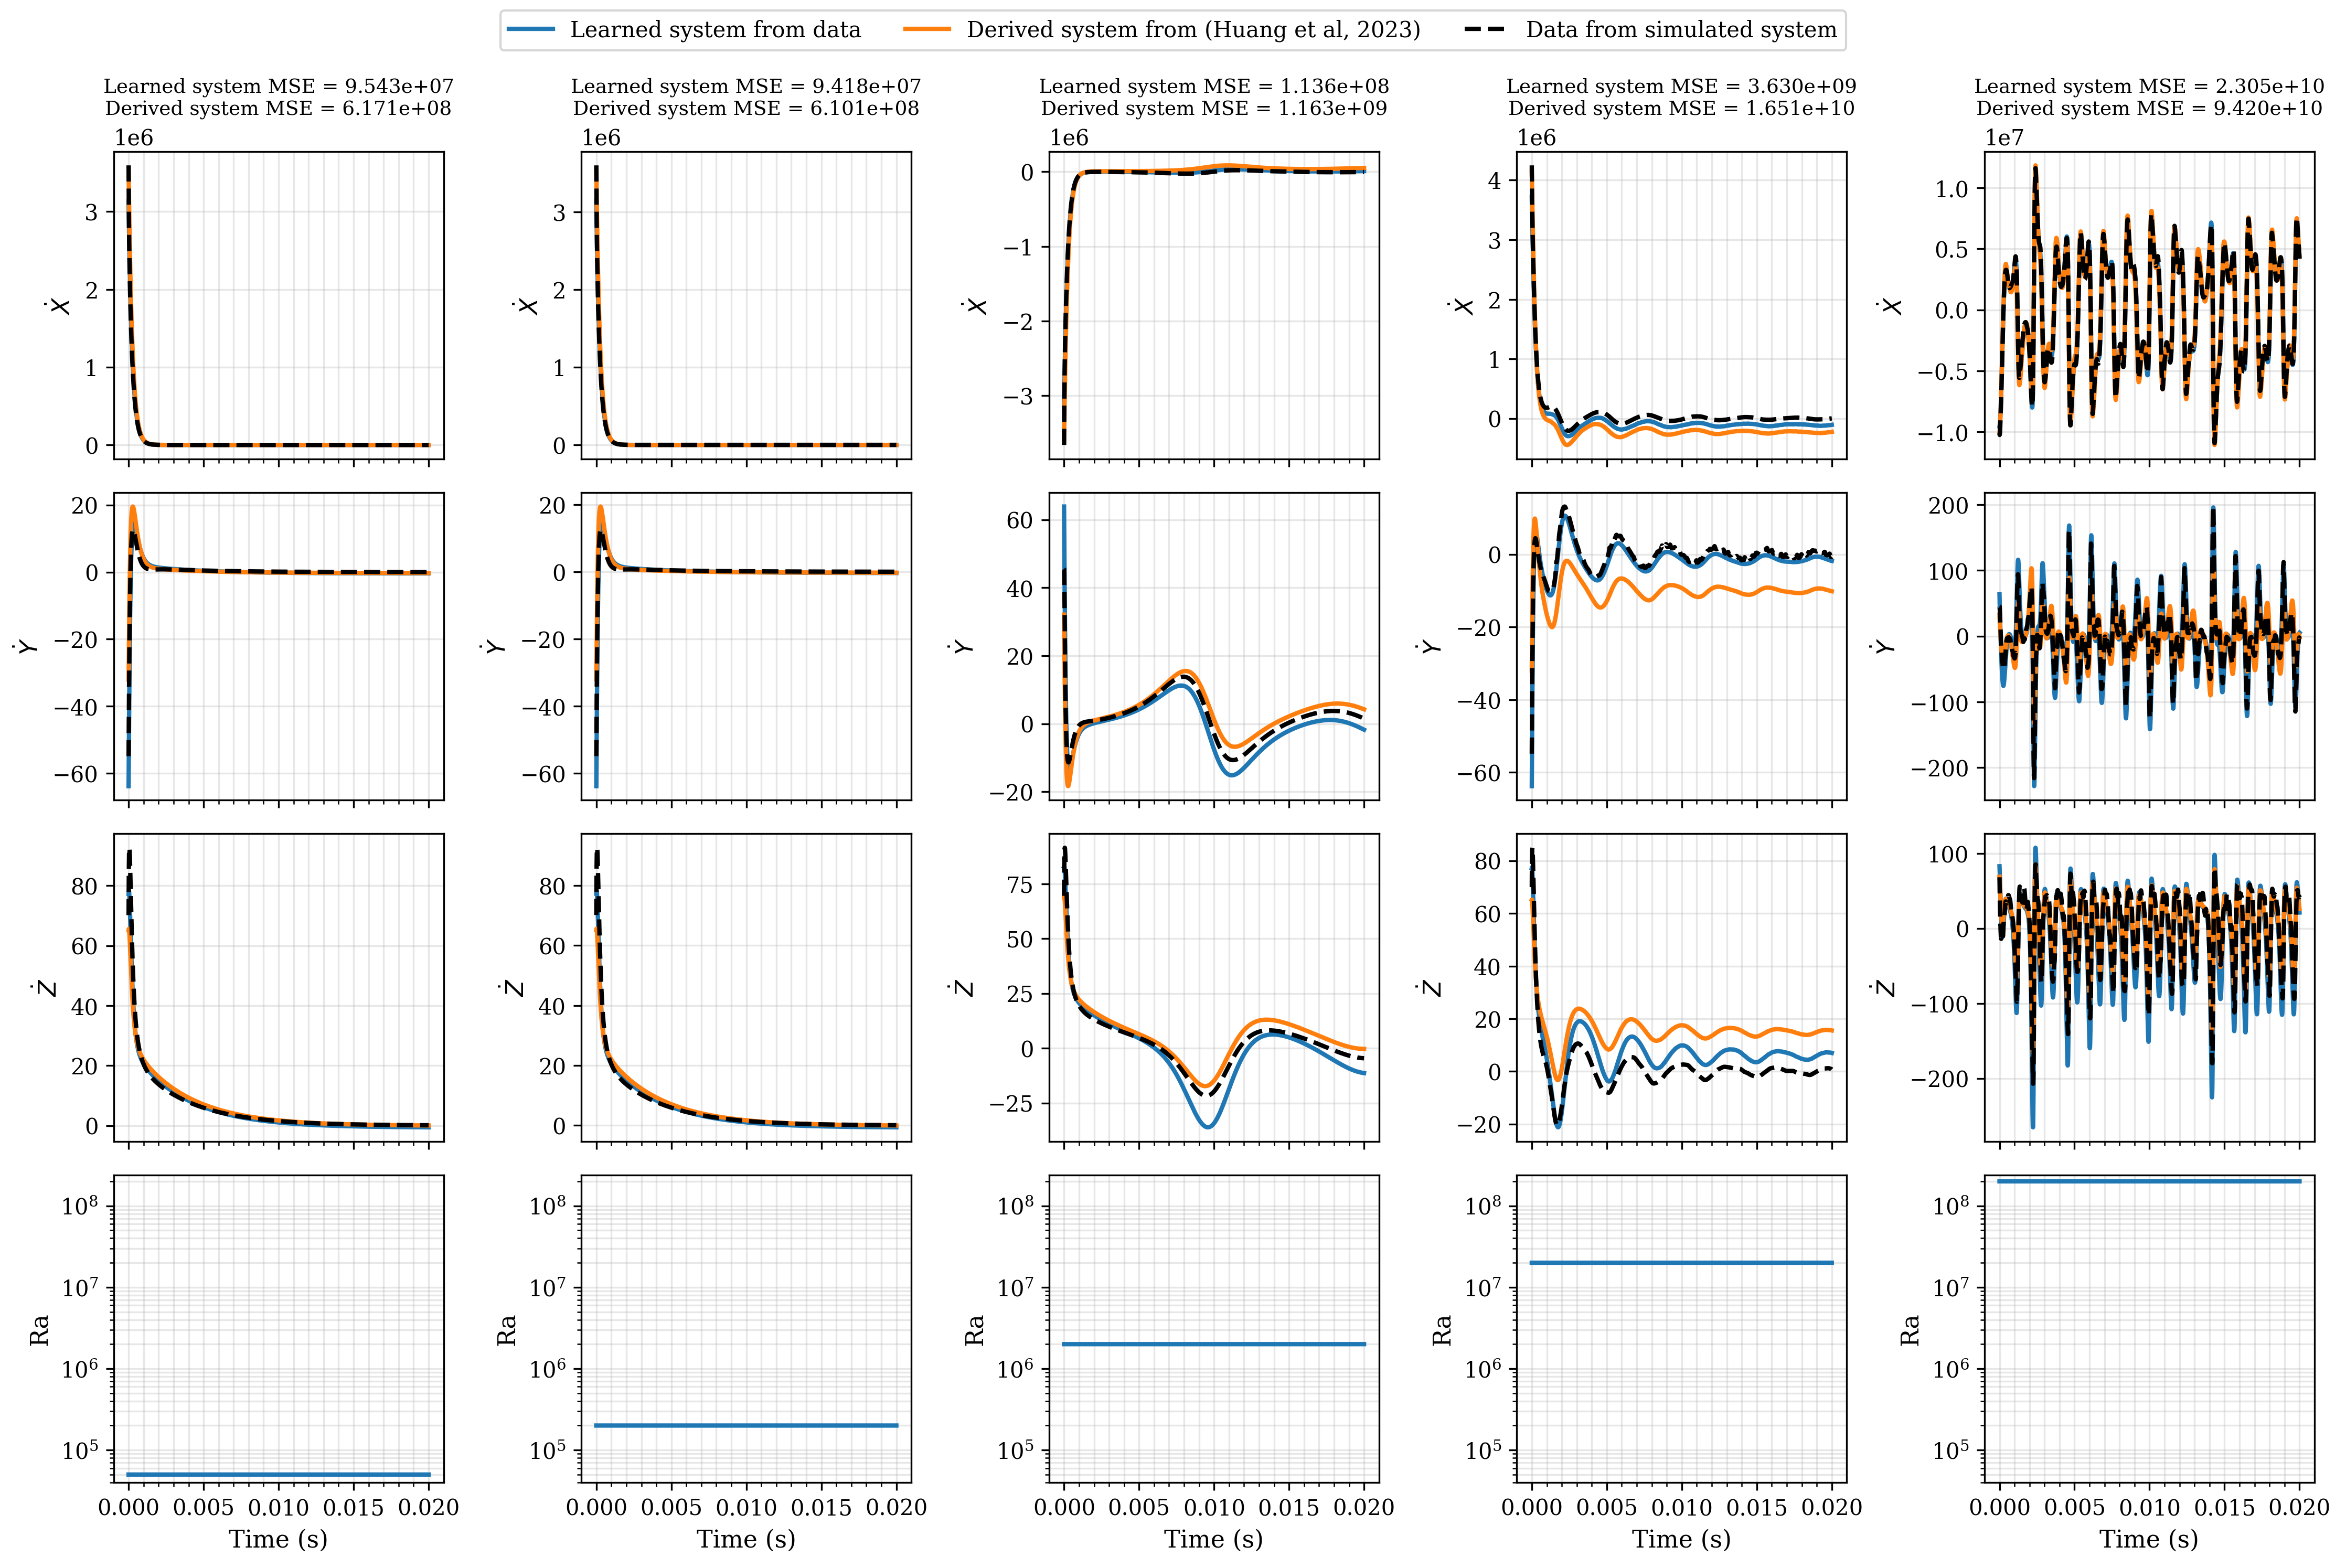

In [48]:
# Define the thermosyphon ODE derived from (Huang et al, 2023)
def thermosyphon_huang(
        t: np.ndarray, x: np.ndarray, u: np.ndarray
) -> np.ndarray:

    return np.array([
        -u[0] * pr * x[1] - alpha * pr * x[0],
        -k * x[0] * (x[2] - y1) - beta * x[1],
        k * x[0] * x[1] - beta * (x[2] - y0)
    ])


# Compare the simulation data with learned system and derived system
fig, axs = plt.subplots(
    4, len(x_valid), sharex=True, figsize=(3*len(x_valid), 10), dpi=300
)

for paramIdx in tqdm(range(len(x_valid))):

    xdot = fd_func._differentiate(x_valid[paramIdx], t_valid[paramIdx])
    xdot_predict = model.predict(x_valid[paramIdx], u_valid[paramIdx])

    xdot_huang = np.zeros_like(xdot_predict)
    for tIdx, tVal in enumerate(t_valid[paramIdx]):
        xdot_huang[tIdx] = thermosyphon_huang(
            tVal, x_valid[paramIdx][tIdx], u_valid[paramIdx][tIdx]
        )

    for stateIdx in range(3):

        if paramIdx == 0 and stateIdx == 0:
            label_sim = {'label': 'Data from simulated system'}
            label_predict = {'label': 'Learned system from data'}
            label_huang = {'label': 'Derived system from (Huang et al, 2023)'}
        else:
            label_sim = {}
            label_predict = {}
            label_huang = {}

        axs[stateIdx, paramIdx].plot(
            t_valid[paramIdx], xdot_predict[:, stateIdx],
            **label_predict
        )
        axs[stateIdx, paramIdx].plot(
            t_valid[paramIdx], xdot_huang[:, stateIdx],
            **label_huang
        )
        axs[stateIdx, paramIdx].plot(
            t_valid[paramIdx], xdot[:, stateIdx], '--k',
            **label_sim
        )
        axs[stateIdx, paramIdx].set_ylabel(
            f'$\dot{{{feature_names[stateIdx]}}}$'
        )

    axs[-1, paramIdx].plot(t_valid[paramIdx], u_valid[paramIdx][:, 0])
    axs[-1, paramIdx].set_ylabel('Ra')
    axs[-1, paramIdx].set_xlabel('Time (s)')
    axs[-1, paramIdx].set_yscale('log')
    axs[-1, paramIdx].set_ylim([
        0.8*min([ra[0,0] for ra in u_list]),
        1.2*max([ra[0,0] for ra in u_list])
    ])

    mse_predict = mean_squared_error(xdot, xdot_predict)
    mse_huang = mean_squared_error(xdot, xdot_huang)
    axs[0, paramIdx].set_title(
        f'Learned system MSE = {mse_predict:.3e}'
        + f'\nDerived system MSE = {mse_huang:.3e}',
        fontsize=9
    )

fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.legend(loc='upper center', ncol=3);

In most cases, the mean squared error from the learned system is an order of magnitude lower than of the derived system. This can be a double-edged sword as with most methods that learn directly from data, the learned model can capture and learn physics that were previously unknown. However, this further highlights the need for high quality data such that we do not introduce undesirable physics that the model may learn.

To summarize the learning in this tutorial:
1. We have learned a parameterized SINDy model using SINDyc and identified the most suitable sparsification threshold parameter using stability selection.
2. Performed a nonlinear system analysis on the learned equation using symbolic maths packages to verify the bifurcation mechanism of the learned nonlinear system.